In [1]:
import sys
sys.path.append("..")

In [15]:
from omegaconf import OmegaConf
from itertools import combinations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os
import re

In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

In [4]:
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset

/Users/c/Library/Caches/pypoetry/virtualenvs/pesto-R9MfnoAy-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from presto import Presto

### Exploring Latent Spaces of Sentence Transformers
Thus far, looking at 
- self-similarity of datasets (noise introduced due to projection), 
- impact of dataset on our assessment,
- impact of n_projections choice on our assessment

Not sure what to make of the results tbh

In [10]:
config = OmegaConf.load("../config.yml")
models = {m: SentenceTransformer(*m.split()) for m in config.models}
datasets = {d: load_dataset(*d.split()) for d in config.datasets}
embeddings = dict()
dataset = config.datasets[0]
n_samples = config.n_samples[0]

for model in models:
    with open(f"embeddings_{re.sub(' ', '___', dataset)}_{n_samples}_{model}.pkl", "rb") as f:
        embeddings[model] = pickle.load(f)

embedding_combinations = list(combinations(embeddings, 2)) + [(e,e) for e in embeddings]

### TODO cleanup
Same dataset, different models, different number of projections (should look at comparisons under PCA w/ different initializations, too)

In [12]:
scores = {c:list() for c in embedding_combinations}
presto_objects = {c:list() for c in embedding_combinations}
for n_projections in config.n_projections[2:3]:
    for e1, e2 in embedding_combinations:
        metric = Presto(max_homology_dim=config.max_homology_dim, n_components=config.n_components, normalize=config.normalize)
        score = metric.fit_transform(embeddings[e1], embeddings[e2], N=n_projections, score_type="aggregate")
        presto_objects[e1,e2].append(metric)
        scores[e1,e2].append(score)
        print(e1, e2, n_projections, score)

all-mpnet-base-v2 all-MiniLM-L6-v2 16 0.16975699624406634
all-mpnet-base-v2 all-distilroberta-v1 16 0.19449708943426838
all-mpnet-base-v2 multi-qa-distilbert-cos-v1 16 0.1447599827309606
all-MiniLM-L6-v2 all-distilroberta-v1 16 0.16415739286879097
all-MiniLM-L6-v2 multi-qa-distilbert-cos-v1 16 0.141268234800346
all-distilroberta-v1 multi-qa-distilbert-cos-v1 16 0.21961972672756228
all-mpnet-base-v2 all-mpnet-base-v2 16 0.1570568112690439
all-MiniLM-L6-v2 all-MiniLM-L6-v2 16 0.18392066687148886
all-distilroberta-v1 all-distilroberta-v1 16 0.2422313146255304
multi-qa-distilbert-cos-v1 multi-qa-distilbert-cos-v1 16 0.15541887386767733


In [24]:
with open(f"presto-objects_cnn_{n_samples}_normalized-{config.normalize}.pkl", "wb") as f:
    pickle.dump(presto_objects, f)
with open(f"scores_cnn_{n_samples}_normalized-{config.normalize}.pkl", "wb") as f:
    pickle.dump(scores, f)

In [26]:
df = pd.DataFrame.from_records(scores)
df["n_projections"] = config.n_projections[:6]
df

,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)","(all-MiniLM-L6-v2, all-distilroberta-v1)","(all-MiniLM-L6-v2, multi-qa-distilbert-cos-v1)","(all-distilroberta-v1, all-distilroberta-v1)","(all-distilroberta-v1, multi-qa-distilbert-cos-v1)","(all-mpnet-base-v2, all-MiniLM-L6-v2)","(all-mpnet-base-v2, all-distilroberta-v1)","(all-mpnet-base-v2, all-mpnet-base-v2)","(all-mpnet-base-v2, multi-qa-distilbert-cos-v1)","(multi-qa-distilbert-cos-v1, multi-qa-distilbert-cos-v1)",n_projections
0,0.295682,0.272834,0.242314,0.281481,0.648453,0.225095,0.358418,0.316168,0.416772,0.224383,4
1,0.167994,0.151546,0.349840,0.310389,0.300237,0.174486,0.299249,0.374607,0.231556,0.241933,8
2,0.277847,0.141369,0.120354,0.274087,0.216557,0.279866,0.152738,0.264671,0.168364,0.237447,16
3,0.205368,0.129020,0.151125,0.205366,0.120048,0.152587,0.090784,0.072832,0.162585,0.118735,32
4,0.134400,0.075782,0.098200,0.076133,0.148071,0.047589,0.095023,0.085921,0.137962,0.055034,64
5,0.046003,0.068635,0.094029,0.107640,0.059286,0.094387,0.110778,0.068069,0.079345,0.106406,128


In [27]:
melted_df = df.melt(id_vars=["n_projections"])
melted_df.head()

,n_projections,variable,value
0,4,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.295682
1,8,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.167994
2,16,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.277847
3,32,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.205368
4,64,"(all-MiniLM-L6-v2, all-MiniLM-L6-v2)",0.134400


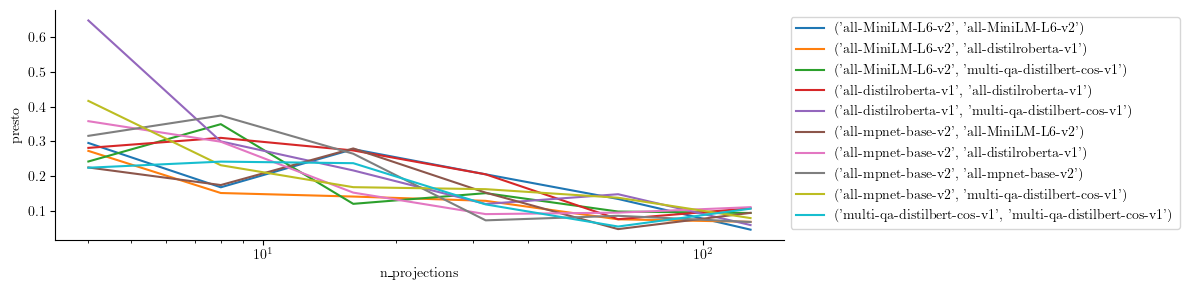

In [29]:
fig, ax = plt.subplots(1,1,figsize=(12,3))
sns.lineplot(melted_df, x="n_projections", y="value", hue="variable")
sns.despine(fig)
ax.set_xscale("log")
ax.set_ylabel("presto")
plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f"presto_cnn_{n_samples}_scores.pdf", bbox_inches="tight", transparent=True)

In [18]:
x = -1
[np.linalg.norm(presto_objects[('all-mpnet-base-v2', 'all-mpnet-base-v2')][x]._all_landscapesY[2][i])
for i in range(len(presto_objects[('all-mpnet-base-v2', 'all-mpnet-base-v2')][x]._all_landscapesY[2]))][:4]

[0.060020834927169385,
 0.08458791469718936,
 0.06974507997283583,
 0.046661467785537425]